In [ ]:
import pandas as pd
import json

with open('../Data/splits_emotion_recognition.json', 'r') as f:
    data = json.load(f)

# Flatten nested structures
df = pd.DataFrame(data["train"])


In [2]:
df["author"] = df["song_author"].apply(lambda x: x[0] if x else None)

In [3]:
top5artists = df.groupby(["label", "author"]).count().sort_values(["label", "song_title"], ascending=[True, False]).groupby("label").head(5)

In [4]:
top5artists = top5artists[["song_title"]].reset_index()

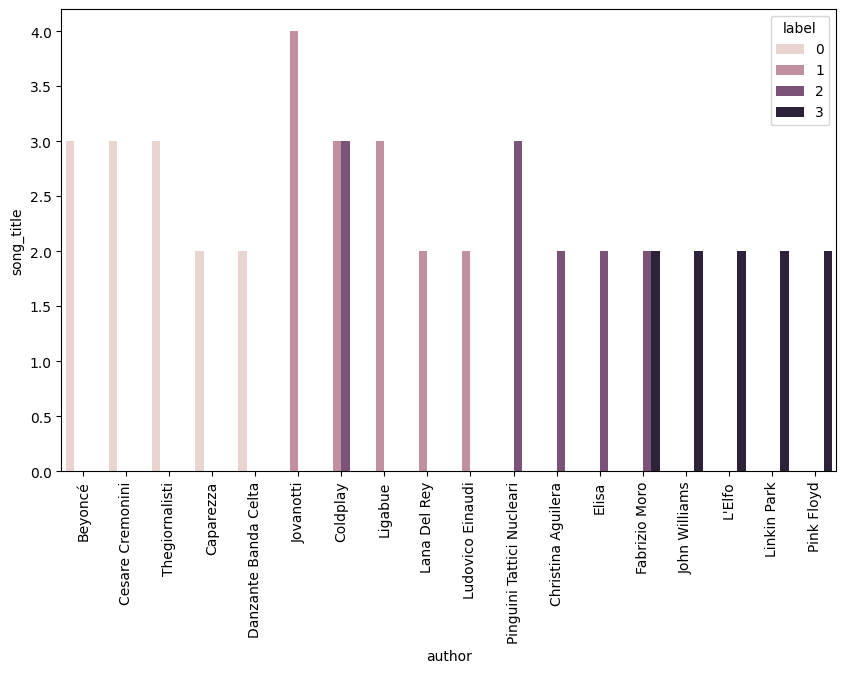

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10,6))

sns.barplot(data=top5artists, x="author", y="song_title", hue="label")
plt.xticks(rotation=90)
plt.show()

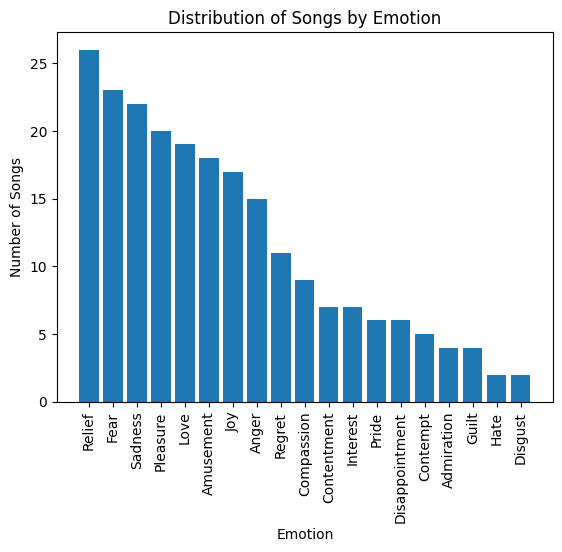

In [6]:
plt.bar(df.value_counts("emotion").index,df.value_counts("emotion"))
plt.xlabel("Emotion")
plt.ylabel("Number of Songs")
plt.title("Distribution of Songs by Emotion")
plt.xticks(rotation=90)
plt.show()

In [7]:
df

,spotify_track_id,song_title,label,emotion,session_type,subject_id,id,song_author,author
0,06s6aloy62vytl3MnT6gfl,Times Like These - Live at the Pantages Theatr...,0,Amusement,personal,23,3784258358,[Foo Fighters],Foo Fighters
1,0h9fnCSnbUgOEgibnQByFv,Everyday Life,2,Disappointment,personal,23,2395445698,[Coldplay],Coldplay
2,1iArQTuOzxvrtniGmkyy92,Burden In My Hand,3,Anger,personal,23,3049220457,[Soundgarden],Soundgarden
3,3A9vIxzGBjEfqmDK7H9exS,Pyramid Song,3,Fear,personal,23,2667905835,[Radiohead],Radiohead
4,39kHMfF3dBMZMbOtoit1XF,On The Mend,0,Joy,personal,23,1281311748,[Foo Fighters],Foo Fighters
...,...,...,...,...,...,...,...,...,...
218,0pVfvpMSFsabyuydMihDi1,Ho amato tutto,1,Love,other,4,7081425536,[Tosca],Tosca
219,3spdoTYpuCpmq19tuD0bOe,My Way,1,Relief,other,4,5527955318,[Frank Sinatra],Frank Sinatra
220,0FB5ILDICqwK6xj7W1RP9u,Hall of Fame,0,Amusement,other,4,1424199427,[The Script],The Script
221,4qFLzh0BSi0KpPYbTWHENQ,Partirò,3,Hate,other,4,3966019638,[Nesli],Nesli


In [9]:
import numpy as np

In [10]:
df["valence"] = np.where(df["label"].isin([0, 1]), 1, 0)
df["power"] = np.where(df["label"].isin([0, 3]), 1, 0)

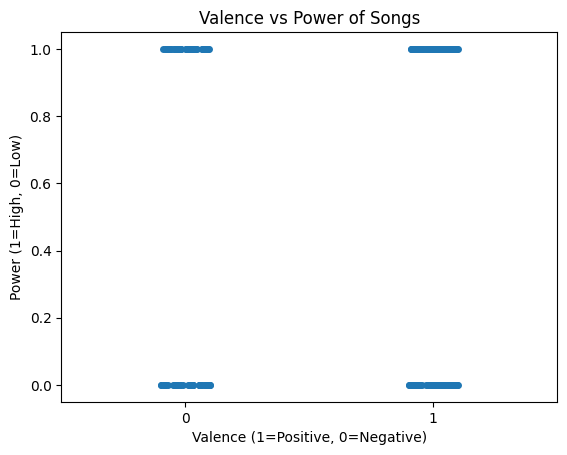

In [15]:
sns.stripplot(x="valence", y="power", data=df, jitter=True)
plt.xlabel("Valence (1=Positive, 0=Negative)")
plt.ylabel("Power (1=High, 0=Low)")
plt.title("Valence vs Power of Songs")
plt.show()